# **Introduction to Trackbars in OpenCV**
Why should you care about trackbars?

A trackbar is OpenCV's built-in slider widget. It attaches itself to a window and lets you change a numeric value live, while watching the image update in real time — no re-running, no guessing, no laptop-throwing. Drag the slider, see the result instantly.

This one small tool is the gateway into building interactive computer vision applications: color calibration tools, threshold tuners, blend/opacity controls, HSV range pickers for object tracking — almost anything where a human needs to feel out the right parameter by eye.

By the end of this notebook, you'll be able to build one from scratch and understand exactly what every line is doing (not just copy-paste it and hope).

---

## **The Syntax: `cv2.createTrackbar()`**

Every trackbar in OpenCV is created using one function:

```python
cv2.createTrackbar(
    trackbar_name,
    window_name,
    initial_value,
    max_value,
    callback_function
)
```

| Parameter | Type | Description |
|-----------|------|-------------|
| **trackbar_name** | `str` | The label displayed next to the slider. |
| **window_name** | `str` | The window the slider belongs to. This window **must already exist**. |
| **initial_value** | `int` | The starting position of the slider. |
| **max_value** | `int` | The maximum slider value. The minimum is always **0**. |
| **callback_function** | `function` | A function that OpenCV automatically calls whenever the slider moves. |

> **Important:** Trackbars only work with **integers**. If you need floating-point values (for example, `0.75`), you'll usually scale the integer value yourself.

---

## **Step 1 — The World's Simplest Trackbar**

Before making a trackbar control something useful, let's create one that simply exists.

Its purpose is to understand the structure of a trackbar without worrying about the logic yet.

Run this program and you'll see:

- a black window
- one slider labeled **Brightness**
- a slider that moves from **0** to **255**

Even though the slider moves, **nothing happens to the image**.

That's expected—we've only built the plumbing. Next, we'll understand each piece individually.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def nothing(value):
    pass

cv2.namedWindow("Window1")
screen = np.zeros((512, 512, 3), dtype=np.uint8)

cv2.createTrackbar("Brightness", "Window1", 0, 255, nothing)

while True:
    cv2.imshow("Window1", screen)
    if cv2.waitKey(1) & 0xff == 27:
        break

cv2.destroyAllWindows()

## **Why Does the Callback Function Have to Exist?**

```python
def do_nothing(x):
    pass
```

This is one of the most confusing parts for beginners.

The fifth parameter of `cv2.createTrackbar()` **must always be a function**.

OpenCV internally expects a callback whenever the slider changes position. 
The the x parameter is the value of the slider.
Because of that:

- You **cannot** omit the callback.
- You **cannot** pass `None`.
- You **must** provide a callable function.

If you don't want anything to happen yet, simply provide an empty function.

```python
def do_nothing(x):
    pass
```

This function satisfies OpenCV's requirement while intentionally doing nothing.

---

## **Why `namedWindow()` Comes First**

```python
cv2.namedWindow("My Window")
```

A trackbar cannot exist by itself.

It must attach to an existing OpenCV window.

Think of it like hanging a shelf on a wall:

- `namedWindow()` builds the wall.
- `createTrackbar()` mounts the shelf.

Without the wall, there is nowhere to attach the shelf.

Although some OpenCV versions create the window automatically, relying on that behavior isn't recommended because it isn't consistent across platforms.

Creating the window explicitly is considered best practice.

---

## **Why Do We Need a `while True` Loop?**

```python
while True:
    cv2.imshow("My Window", img)

    if cv2.waitKey(1) & 0xFF == 27:
        break
```

OpenCV windows are **not continuously refreshed automatically**.

Instead, your program must repeatedly:

1. display the current image,
2. process keyboard events,
3. process mouse events,
4. process trackbar events,
5. redraw the window.

That's exactly what this loop does.

Without it, the window would appear frozen or become unresponsive.

---

## **Understanding `cv2.waitKey(1)`**

```python
cv2.waitKey(1)
```

This function waits **up to 1 millisecond** for a key press.

During this tiny delay, OpenCV also:

- refreshes the window,
- checks keyboard input,
- handles mouse events,
- updates trackbars.

That's why almost every OpenCV program contains a `waitKey()` call inside a loop.

Without it, your GUI would stop responding.

---

## **Why `& 0xFF`?**

```python
cv2.waitKey(1) & 0xFF
```

Depending on your operating system, `waitKey()` can return values larger than one byte.

The bitwise operation

```python
& 0xFF
```

keeps only the lowest 8 bits, making keyboard comparisons consistent across different platforms.

You'll see this pattern in countless OpenCV programs.

```python
if cv2.waitKey(1) & 0xFF == 27:
```

Here, **27** is the ASCII code for the **Escape (Esc)** key.

---

## **Cleaning Up**

```python
cv2.destroyAllWindows()
```

Once the loop ends, we close every OpenCV window.

This is good practice because it releases the GUI resources used by OpenCV.

In environments such as Jupyter Notebook, forgetting this step can sometimes leave windows open or cause unexpected behavior.

---

## **Recap**

At this point, we've built a trackbar that is completely wired up but intentionally does nothing.

We learned that:

- A window must exist before a trackbar can attach to it.
- Every trackbar requires a callback function.
- The callback must accept one parameter.
- A continuous loop keeps the GUI responsive.
- `waitKey()` processes GUI events.
- Pressing **Esc** exits the program.
- `destroyAllWindows()` cleans everything up.

What's still missing?

Although the slider moves, **nothing in our program actually reads its value or uses it to modify the image**.

---
In the next section, we'll finally make the slider useful and explore two common approaches:

1. **Using callbacks** to react immediately whenever the slider changes.
2. **Polling the trackbar value** inside the main loop using `cv2.getTrackbarPos()`.

Both approaches are widely used in OpenCV, and understanding when to use each is an important skill.

## **Strategy A— Event-driven (Callback does the work)**

Strategy A is a pattern where the actual logic of your program lives directly inside the callback function you pass to cv2.createTrackbar. OpenCV automatically calls this function every time the slider moves, handing it the new position as an argument — and that single call is responsible for computing the new result and redrawing it on screen.

In short: the slider pushes a value to you, and your function reacts immediately. You never have to ask "what's the current value?" — OpenCV already tells you, every time it changes.

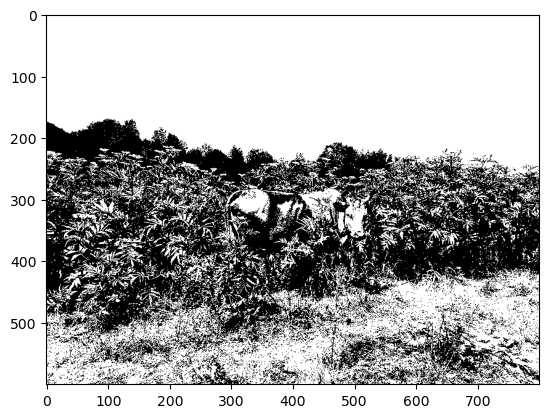

In [12]:
# Load any image in grayscale. 
#Create a single trackbar labeled "Threshold" ranging from 0–255. 
#As you move it,apply cv2.threshold() using that value and display the result live, 
#so you can visually find the cutoff that best separates foreground from background.

import cv2
import matplotlib.pyplot as plt

WINDOW = "Window1"
TRACKBAR = "Threshold"

def update_threshold(value):
    global result
    _, result = cv2.threshold(screen, value, 255, cv2.THRESH_BINARY)
    cv2.imshow(WINDOW, result)

screen = cv2.imread(r"C:\Users\DELL\Desktop\resources\ComputerVision\Computer Vision\Computer Vision Sessions\02s\pic2\input.jpg", cv2.IMREAD_GRAYSCALE)
cv2.namedWindow(WINDOW)

cv2.createTrackbar(TRACKBAR, WINDOW, 0, 255, update_threshold)
update_threshold(0)

cv2.waitKey()
cv2.destroyAllWindows()

plt.imshow(result, cmap="gray")
plt.show()

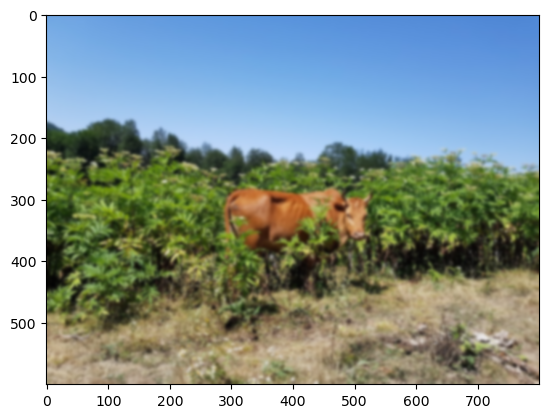

In [16]:
# Load a color image. 
#Create a trackbar labeled "Kernel Size" ranging from 1–25. 
#Use its value as the kernel size for cv2.GaussianBlur() (careful: the kernel size must be an odd number — you'll need to handle that yourself).
#Display the blurred result live as the slider moves.

import cv2
import matplotlib.pyplot as plt

WINDOW = "Window2"
TRACKBAR = "Kernel Size"
screen = cv2.imread(r"C:\Users\DELL\Desktop\resources\ComputerVision\Computer Vision\Computer Vision Sessions\02s\pic2\input.jpg")

def update_kernel_size(value):
    global result
    if value % 2 == 0:
        value += 1
        result = cv2.GaussianBlur(screen, (value, value), 0)
    cv2.imshow(WINDOW, result)

cv2.namedWindow(WINDOW)
cv2.createTrackbar(TRACKBAR, WINDOW, 1, 25, update_kernel_size)
update_kernel_size(0)

cv2.waitKey()
cv2.destroyAllWindows()

plt.imshow(result[..., ::-1])
plt.show()

In [6]:
import cv2
import numpy as np

def update_background(value):
    screen[:] = value
    cv2.imshow("Window2", screen)

cv2.namedWindow("Window2")
screen = np.zeros((512, 512), dtype=np.uint8)

cv2.createTrackbar("Background", "Window2", 0, 255, update_background)
update_background(0)

cv2.waitKey()
cv2.destroyAllWindows()

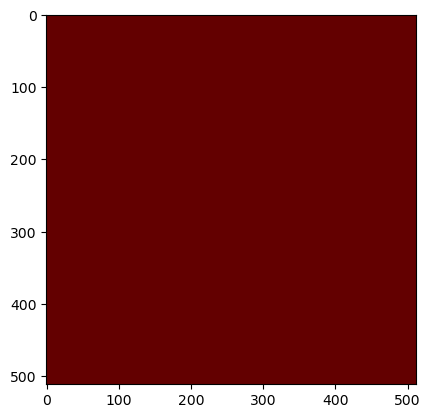

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

WINDOW_NAME = "Window3"
TRACKBAR_NAME = "Brightness"

def update_background(value):
    screen[..., 2] = value
    cv2.imshow(WINDOW_NAME, screen)

cv2.namedWindow(WINDOW_NAME)
screen = np.zeros((512, 512, 3), dtype=np.uint8)

cv2.createTrackbar(TRACKBAR_NAME, WINDOW_NAME, 0, 255, update_background)
# manually calling the callback once, before the user interacts with anything, so the window shows an initial result rather than starting blank.
update_background(0)

cv2.waitKey()
cv2.destroyAllWindows()

plt.imshow(screen[..., ::-1])
plt.show()

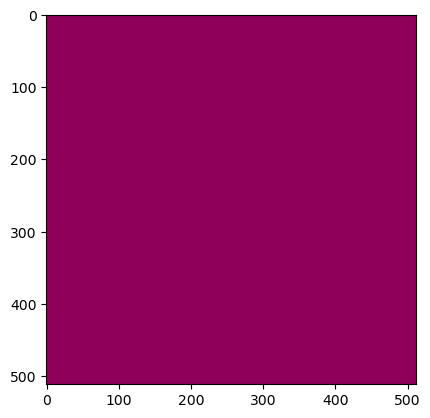

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

WINDOW_NAME = "Window4"

def update_background_blue(value):
    screen[..., 0] = value
    cv2.imshow(WINDOW_NAME, screen)
    
def update_background_green(value):
    screen[..., 1] = value
    cv2.imshow(WINDOW_NAME, screen)

def update_background_red(value):
    screen[..., 2] = value
    cv2.imshow(WINDOW_NAME, screen)

cv2.namedWindow(WINDOW_NAME)
screen = np.zeros((512, 512, 3), dtype=np.uint8)

cv2.createTrackbar("Blue Brightness", WINDOW_NAME, 0, 255, update_background_blue)
cv2.createTrackbar("Green Brightness", WINDOW_NAME, 0, 255, update_background_green)
cv2.createTrackbar("Red Brightness", WINDOW_NAME, 0, 255, update_background_red)

update_background_blue(0)
update_background_green(0)
update_background_red(0)

cv2.waitKey()
cv2.destroyAllWindows()

plt.imshow(screen[..., ::-1])
plt.show()

## **Strategy B — The Polling-Based Trackbar**
Strategy B is a pattern where the callback function passed to cv2.createTrackbar is intentionally left empty — a no-op required only to satisfy OpenCV's API. The actual logic of your program lives instead inside a while True loop, which repeatedly and manually asks OpenCV "what is the slider's value right now?" using cv2.getTrackbarPos().

In short: you actively pull the value from OpenCV, over and over, rather than being notified when it changes. This is called polling — repeatedly checking a state instead of reacting to an event.

---
### **Why the callback still has to exist — but does nothing?**
```python
def nothing(x):
    pass
````
createTrackbar's API always requires a callback argument — that's non-negotiable, a consequence of OpenCV's underlying C++ design. You can never pass None or skip it entirely.

But in Strategy B, we genuinely don't want anything to happen automatically the instant the slider moves. So we hand OpenCV a function that technically satisfies the requirement while doing absolutely nothing — a permanent placeholder, not a temporary one. All real logic is deliberately kept outside of it.

---

### **Where the real logic actually lives?**
```python
while True:
    cv2.imshow("image", image)
    if cv2.waitKey(1) & 0xff == 27:
        break

    r = cv2.getTrackbarPos("R", "image")
    g = cv2.getTrackbarPos("G", "image")
    b = cv2.getTrackbarPos("B", "image")
    s = cv2.getTrackbarPos(switch, "image")

    if s == 0:
        image[:] = 0
    else:
        image[:] = [b, g, r]
```
Every single iteration of this loop performs the full cycle manually:

Draw the current frame — cv2.imshow(...) displays whatever image currently holds.
Check for exit / process events — cv2.waitKey(1) briefly pauses (1 ms) and lets OpenCV process GUI events, while also checking if the user pressed Esc (27) to quit.
Pull the current values — cv2.getTrackbarPos(name, window) is called once per trackbar, fetching each one's current position on demand. Nobody notifies you of a change; you simply ask, every loop.
Recompute the result — using whatever values were just read, the image is updated (image[:] = [b, g, r]), factoring in all four sliders together (R, G, B, and the switch).

This is the defining trait of Strategy B: the loop drives everything — reading, computing, and drawing all happen together, on a repeating cycle, independent of the (empty) callback.

---

### **Why the while True loop is essential here?**

In Strategy A, the callback itself handled redrawing, so a single blocking cv2.waitKey() was enough. In Strategy B, nothing else is refreshing the display or checking slider values for you — if you called getTrackbarPos just once outside a loop, you'd capture a single snapshot and never see updates again, no matter how much the user dragged the sliders afterward.

The loop is what gives Strategy B its "live" feeling — it takes over the job the callback used to do in Strategy A, at the cost of repeatedly doing that work (dozens of times per second) even when nothing has actually changed.

---

### **When to reach for Strategy B?**

Use the polling pattern when:

- Multiple trackbars need to be combined together before you can compute a result — like needing R, G, B, and the switch all at once to know the final color.
- You want to mix trackbar input with other input types (keyboard shortcuts, mouse events, timers) inside one unified loop.
- You're building something closer to a full interactive application, where keeping all state-reading logic in one predictable place scales better than scattering it across several separate callback functions.
